<a href="https://colab.research.google.com/github/luckyKumar37/fashion_mnist_with_pytroch/blob/main/CNN_on_fashion_mnist_with_pytroch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset,Dataset,DataLoader,random_split
from torchvision import datasets,transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random


def set_seed(seed=42):
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  random.seed(seed)
  np.random.seed(seed)


set_seed()

In [23]:
transform=transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root='/content/',
    train=True,
    download=True,
    transform=transform
)

In [24]:
train_size = int(0.8*len(train_dataset))
val_size = len(train_dataset) - train_size


train_dataset,val_dataset  = random_split(
    train_dataset,
    [train_size,val_size]
)


train_loader = DataLoader(
    train_dataset,
    batch_size = 64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)



In [25]:
test_dataset = datasets.FashionMNIST(
    root = '/content/',
    train = False,
    download=True,
    transform = transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)




In [26]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

48000
12000
10000


In [27]:
image,label = train_dataset[0]

image.shape


torch.Size([1, 28, 28])

In [28]:
class CNN(nn.Module):
  def __init__(self,input_size):
    super().__init__()

    self.Extraction = nn.Sequential(
        nn.Conv2d(input_size,32,kernel_size=3,padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2,stride=2),

        nn.Conv2d(32,64,kernel_size=3,padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(7*7*64,128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(64,10)

    )

  def forward(self,x):
    x = self.Extraction(x)

    return self.classifier(x)

In [29]:

image,label = train_dataset[0]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


model = CNN(image.shape[0]).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(),lr=1e-3,weight_decay=1e-4)

In [30]:
pip install torchinfo


In [31]:
from torchinfo import summary

summary(model,input_size=(64,1,28,28))

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [64, 10]                  --
├─Sequential: 1-1                        [64, 64, 7, 7]            --
│    └─Conv2d: 2-1                       [64, 32, 28, 28]          320
│    └─ReLU: 2-2                         [64, 32, 28, 28]          --
│    └─BatchNorm2d: 2-3                  [64, 32, 28, 28]          64
│    └─MaxPool2d: 2-4                    [64, 32, 14, 14]          --
│    └─Conv2d: 2-5                       [64, 64, 14, 14]          18,496
│    └─ReLU: 2-6                         [64, 64, 14, 14]          --
│    └─BatchNorm2d: 2-7                  [64, 64, 14, 14]          128
│    └─MaxPool2d: 2-8                    [64, 64, 7, 7]            --
├─Sequential: 1-2                        [64, 10]                  --
│    └─Flatten: 2-9                      [64, 3136]                --
│    └─Linear: 2-10                      [64, 128]                 401,536
│   

In [32]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

epochs = 20

for epoch in range(epochs):

  # training

  model.train()

  train_loss = 0
  train_correct = 0
  train_total = 0

  for X_batch,y_batch in train_loader:

    X_batch,y_batch = X_batch.to(device),y_batch.to(device)

    output = model(X_batch)

    loss = criterion(output,y_batch)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()


    train_loss += loss.item()

    prediction = torch.argmax(output,dim=1)

    train_correct += (prediction == y_batch).sum().item()

    train_total += y_batch.size(0)

  train_loss /= len(train_loader)
  train_accuracy = train_correct/train_total


  # validation

  model.eval()

  val_loss = 0
  val_correct = 0
  val_total = 0

  with torch.no_grad():

    for X_batch,y_batch in val_loader:

      X_batch,y_batch = X_batch.to(device),y_batch.to(device)

      output = model(X_batch)

      loss = criterion(output,y_batch)

      val_loss += loss.item()

      prediction = torch.argmax(output,dim=1)

      val_correct += (prediction == y_batch).sum().item()

      val_total += y_batch.size(0)


  val_loss /=len(val_loader)
  val_accuracy = val_correct/val_total


  train_losses.append(train_loss)
  train_accuracies.append(train_accuracy)

  val_losses.append(val_loss)
  val_accuracies.append(val_accuracy)


  print(
      f"Epoch [{epoch+1}/{epochs}] "
      f"Train Loss: {train_loss:.4f} "
      f"Val Loss: {val_loss:.4f} "
      f"Train Acc: {train_accuracy:.4f} "
      f"Val Acc: {val_accuracy:.4f}"
  )







Epoch [1/20] Train Loss: 0.4557 Val Loss: 0.2919 Train Acc: 0.8393 Val Acc: 0.8956
Epoch [2/20] Train Loss: 0.2938 Val Loss: 0.2828 Train Acc: 0.8944 Val Acc: 0.8993
Epoch [3/20] Train Loss: 0.2515 Val Loss: 0.2359 Train Acc: 0.9104 Val Acc: 0.9147
Epoch [4/20] Train Loss: 0.2256 Val Loss: 0.2605 Train Acc: 0.9193 Val Acc: 0.9066
Epoch [5/20] Train Loss: 0.2001 Val Loss: 0.2350 Train Acc: 0.9284 Val Acc: 0.9159
Epoch [6/20] Train Loss: 0.1833 Val Loss: 0.2545 Train Acc: 0.9349 Val Acc: 0.9163
Epoch [7/20] Train Loss: 0.1692 Val Loss: 0.2988 Train Acc: 0.9390 Val Acc: 0.9057
Epoch [8/20] Train Loss: 0.1616 Val Loss: 0.2952 Train Acc: 0.9416 Val Acc: 0.9018
Epoch [9/20] Train Loss: 0.1446 Val Loss: 0.2545 Train Acc: 0.9466 Val Acc: 0.9175
Epoch [10/20] Train Loss: 0.1419 Val Loss: 0.2475 Train Acc: 0.9491 Val Acc: 0.9205
Epoch [11/20] Train Loss: 0.1348 Val Loss: 0.2511 Train Acc: 0.9516 Val Acc: 0.9222
Epoch [12/20] Train Loss: 0.1218 Val Loss: 0.2701 Train Acc: 0.9557 Val Acc: 0.9224
E

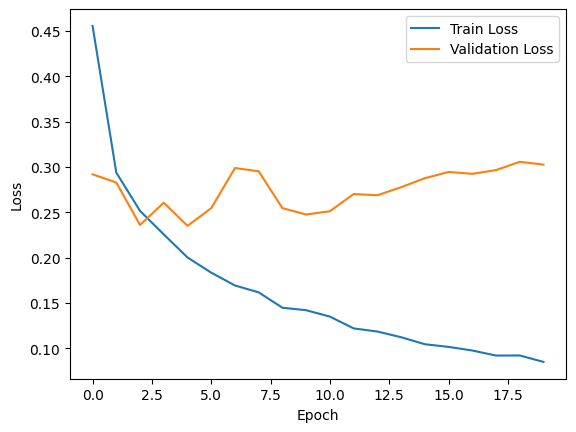

In [33]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)


        predictions = torch.argmax(outputs, dim=1)


        probabilities = torch.softmax(outputs, dim=1)

        all_preds.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            y_batch.cpu().numpy()
        )

        all_probs.extend(
            probabilities.cpu().numpy()
        )



accuracy = accuracy_score(
    all_labels,
    all_preds
)



precision = precision_score(
    all_labels,
    all_preds,
    average="weighted"
)



recall = recall_score(
    all_labels,
    all_preds,
    average="weighted"
)



f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted"
)



auc = roc_auc_score(
    all_labels,
    all_probs,
    multi_class="ovr",
    average="weighted"
)


print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", auc)



print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names = [
            "T-shirt/top",
            "Trouser",
            "Pullover",
            "Dress",
            "Coat",
            "Sandal",
            "Shirt",
            "Sneaker",
            "Bag",
            "Ankle boot"
        ]
    )
)



print("\nConfusion Matrix:")
print(
    confusion_matrix(
        all_labels,
        all_preds
    )
)


Accuracy : 0.9171
Precision: 0.9175450981456014
Recall   : 0.9171
F1 Score : 0.9171686448728249
ROC-AUC  : 0.9944567666666666

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.87      0.87      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.86      0.90      0.88      1000
       Dress       0.93      0.90      0.92      1000
        Coat       0.86      0.88      0.87      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.77      0.76      0.76      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.99      0.97      0.98      1000
  Ankle boot       0.98      0.95      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000


Confusion Matrix:
[[870   0  19   9   3   1  94   0   4   0]
 [  2 985   2   5   4   0   1